In [ ]:
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import xarray as xr


jax.config.update("jax_default_device", jax.devices("gpu")[0])

In [2]:
datadir = Path("../../data")
dataset_xr = xr.open_dataset(
    datadir / "shallow_water_1d_validation_grf_seed=11.hdf5",
    engine="h5netcdf",
    chunks={},
).isel({"t": slice(0, 80)})
dataset_xr

<xarray.Dataset> Size: 1GB
Dimensions:  (ic: 8850, t: 80, dim: 2, x: 100, param: 4)
Coordinates:
  * t        (t) float64 640B 0.0 0.005 0.01 0.015 ... 0.38 0.385 0.39 0.395
  * dim      (dim) <U3 24B 'u_0' 'u_1'
  * x        (x) float64 800B 0.005 0.015 0.025 0.035 ... 0.975 0.985 0.995
  * param    (param) <U7 112B 'gamma' 'alpha' 'beta' 'h_floor'
Dimensions without coordinates: ic
Data variables:
    values   (ic, t, dim, x) float64 1GB dask.array<chunksize=(8850, 80, 2, 100), meta=np.ndarray>
    coeffs   (ic, param) float64 283kB dask.array<chunksize=(8850, 4), meta=np.ndarray>

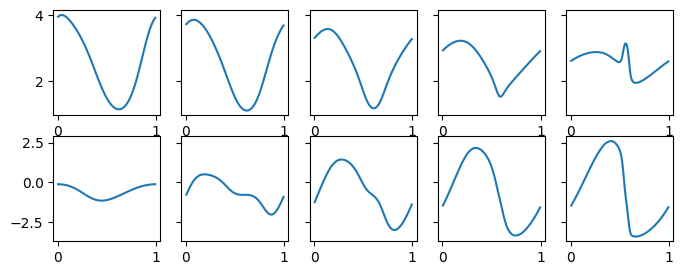

In [4]:
sample_idx = 0
fig, axes = plt.subplots(2, 5, figsize=(8, 3), sharey="row")
for i, axes_row in enumerate(axes):
    for j, ax in enumerate(axes_row):
        ax.plot(dataset_xr.coords["x"], dataset_xr["values"][sample_idx, 10 * j, i])
